https://www.kaggle.com/datasets/rohitgrewal/loan-approval-dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus


In [ ]:
#import and upload data:
from google.colab import files
uploaded = files.upload()

Saving loan_approval_dataset.csv to loan_approval_dataset (3).csv


In [ ]:
df = pd.read_csv('loan_approval_dataset.csv')
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [ ]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
df.rename(columns = {'loan_id':'l_id', ' education':'edu', 'no_of_dependents':'n_dependants', ' self_employed':'s_employed' , ' income_annum':'i_annum', ' loan_amount':'l_amount', ' loan_term':'l_term', ' cibil_score':'c_score', ' residential_assets_value':'r_value', ' commercial_assets_value':'c_value', ' luxury_assets_value':'lux_value', ' bank_asset_value':'b_value', ' loan_status':'l_status'}, inplace=True)
df = df.drop(['l_id','edu'], axis=1)
df


,n_dependants,s_employed,i_annum,l_amount,l_term,c_score,r_value,c_value,lux_value,b_value,l_status
0,2,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [ ]:

le = LabelEncoder()

label = le.fit_transform(df['s_employed'])
label

df.drop('s_employed', axis=1, inplace=True)
df['s_employed'] = label

label = le.fit_transform(df['l_status'])
label

df.drop('l_status', axis=1, inplace=True)
df['l_status'] = label

df

,n_dependants,i_annum,l_amount,l_term,c_score,r_value,c_value,lux_value,b_value,s_employed,l_status
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,1
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,1
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1000000,2300000,12,317,2800000,500000,3300000,800000,1,1
4265,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,0
4266,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,1
4267,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,0,0


In [ ]:
#split dataset in features and target variable
x_data = df[['n_dependants', 'i_annum', 'l_amount', 'l_term', 'c_score', 'r_value', 'c_value', 'lux_value', 'b_value']]
y_data = df['l_status']

In [ ]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(x_data,y_data,test_size=.30, random_state=1)

In [ ]:
# Create Decision Tree classifer object
dt_model = DecisionTreeClassifier()

# Train Decision Tree Classifer
dt_model2 = dt_model.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = dt_model2.predict(X_test)

In [ ]:
# Model Accuracy
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9797033567525371


In [ ]:
print(classification_report(y_test, y_pred))

precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print(f"The precision of the model is {precision:.2f}.")
print(f"The recall of the model is {recall:.2f}.")
print(f"The F1-score of the model is {f1:.2f}.")

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       798
           1       0.97      0.98      0.97       483

    accuracy                           0.98      1281
   macro avg       0.98      0.98      0.98      1281
weighted avg       0.98      0.98      0.98      1281

The precision of the model is 0.97.
The recall of the model is 0.98.
The F1-score of the model is 0.97.


In [ ]:
def predict_loan_approval():
    while True:
        try:
            dependants = int(input("Enter number of dependants: "))
            annum = int(input("Enter income annum: "))
            amount = int(input("Enter loan amount: "))
            term = int(input("Enter loan term: "))
            cibil = int(input("Enter cibil score: "))
            residential = int(input("Enter residential assets value: "))
            commercial = int(input("Enter commercial assests value: "))
            luxury = float(input("Enter luxury assets value: "))
            bank = int(input("Enter bank assets value: "))


            # Input validation (example: check for non-negative values)
            if any(val < 0 for val in [dependants, annum, amount, term, cibil, residential, commercial, luxury, bank]):
                print("Error: Please enter non-negative values for all features.")
                continue  #restart the loop

            new_loan_data = pd.DataFrame([[dependants, annum, amount, term, cibil, residential, commercial, luxury, bank]],
                                           columns=['n_dependants', 'i_annum', 'l_amount', 'l_term', 'c_score', 'r_value', 'c_value', 'lux_value', 'b_value'])

            prediction = dt_model2.predict(new_loan_data)[0]

            if prediction == 1:
                print("Prediction: loan is likely to be approved.")
            else:
                print("Prediction: loan is likely to be rejected.")

            another_loan = input("Enter data for another loan? (yes/no): ")
            if another_loan.lower() != 'yes':
                break #exit loop
        except ValueError:
            print("Invalid input. Please enter valid numerical values.")

predict_loan_approval()

KeyboardInterrupt: Interrupted by user

In [ ]:
!pip install graphviz
!pip install pydotplus
!pip install six

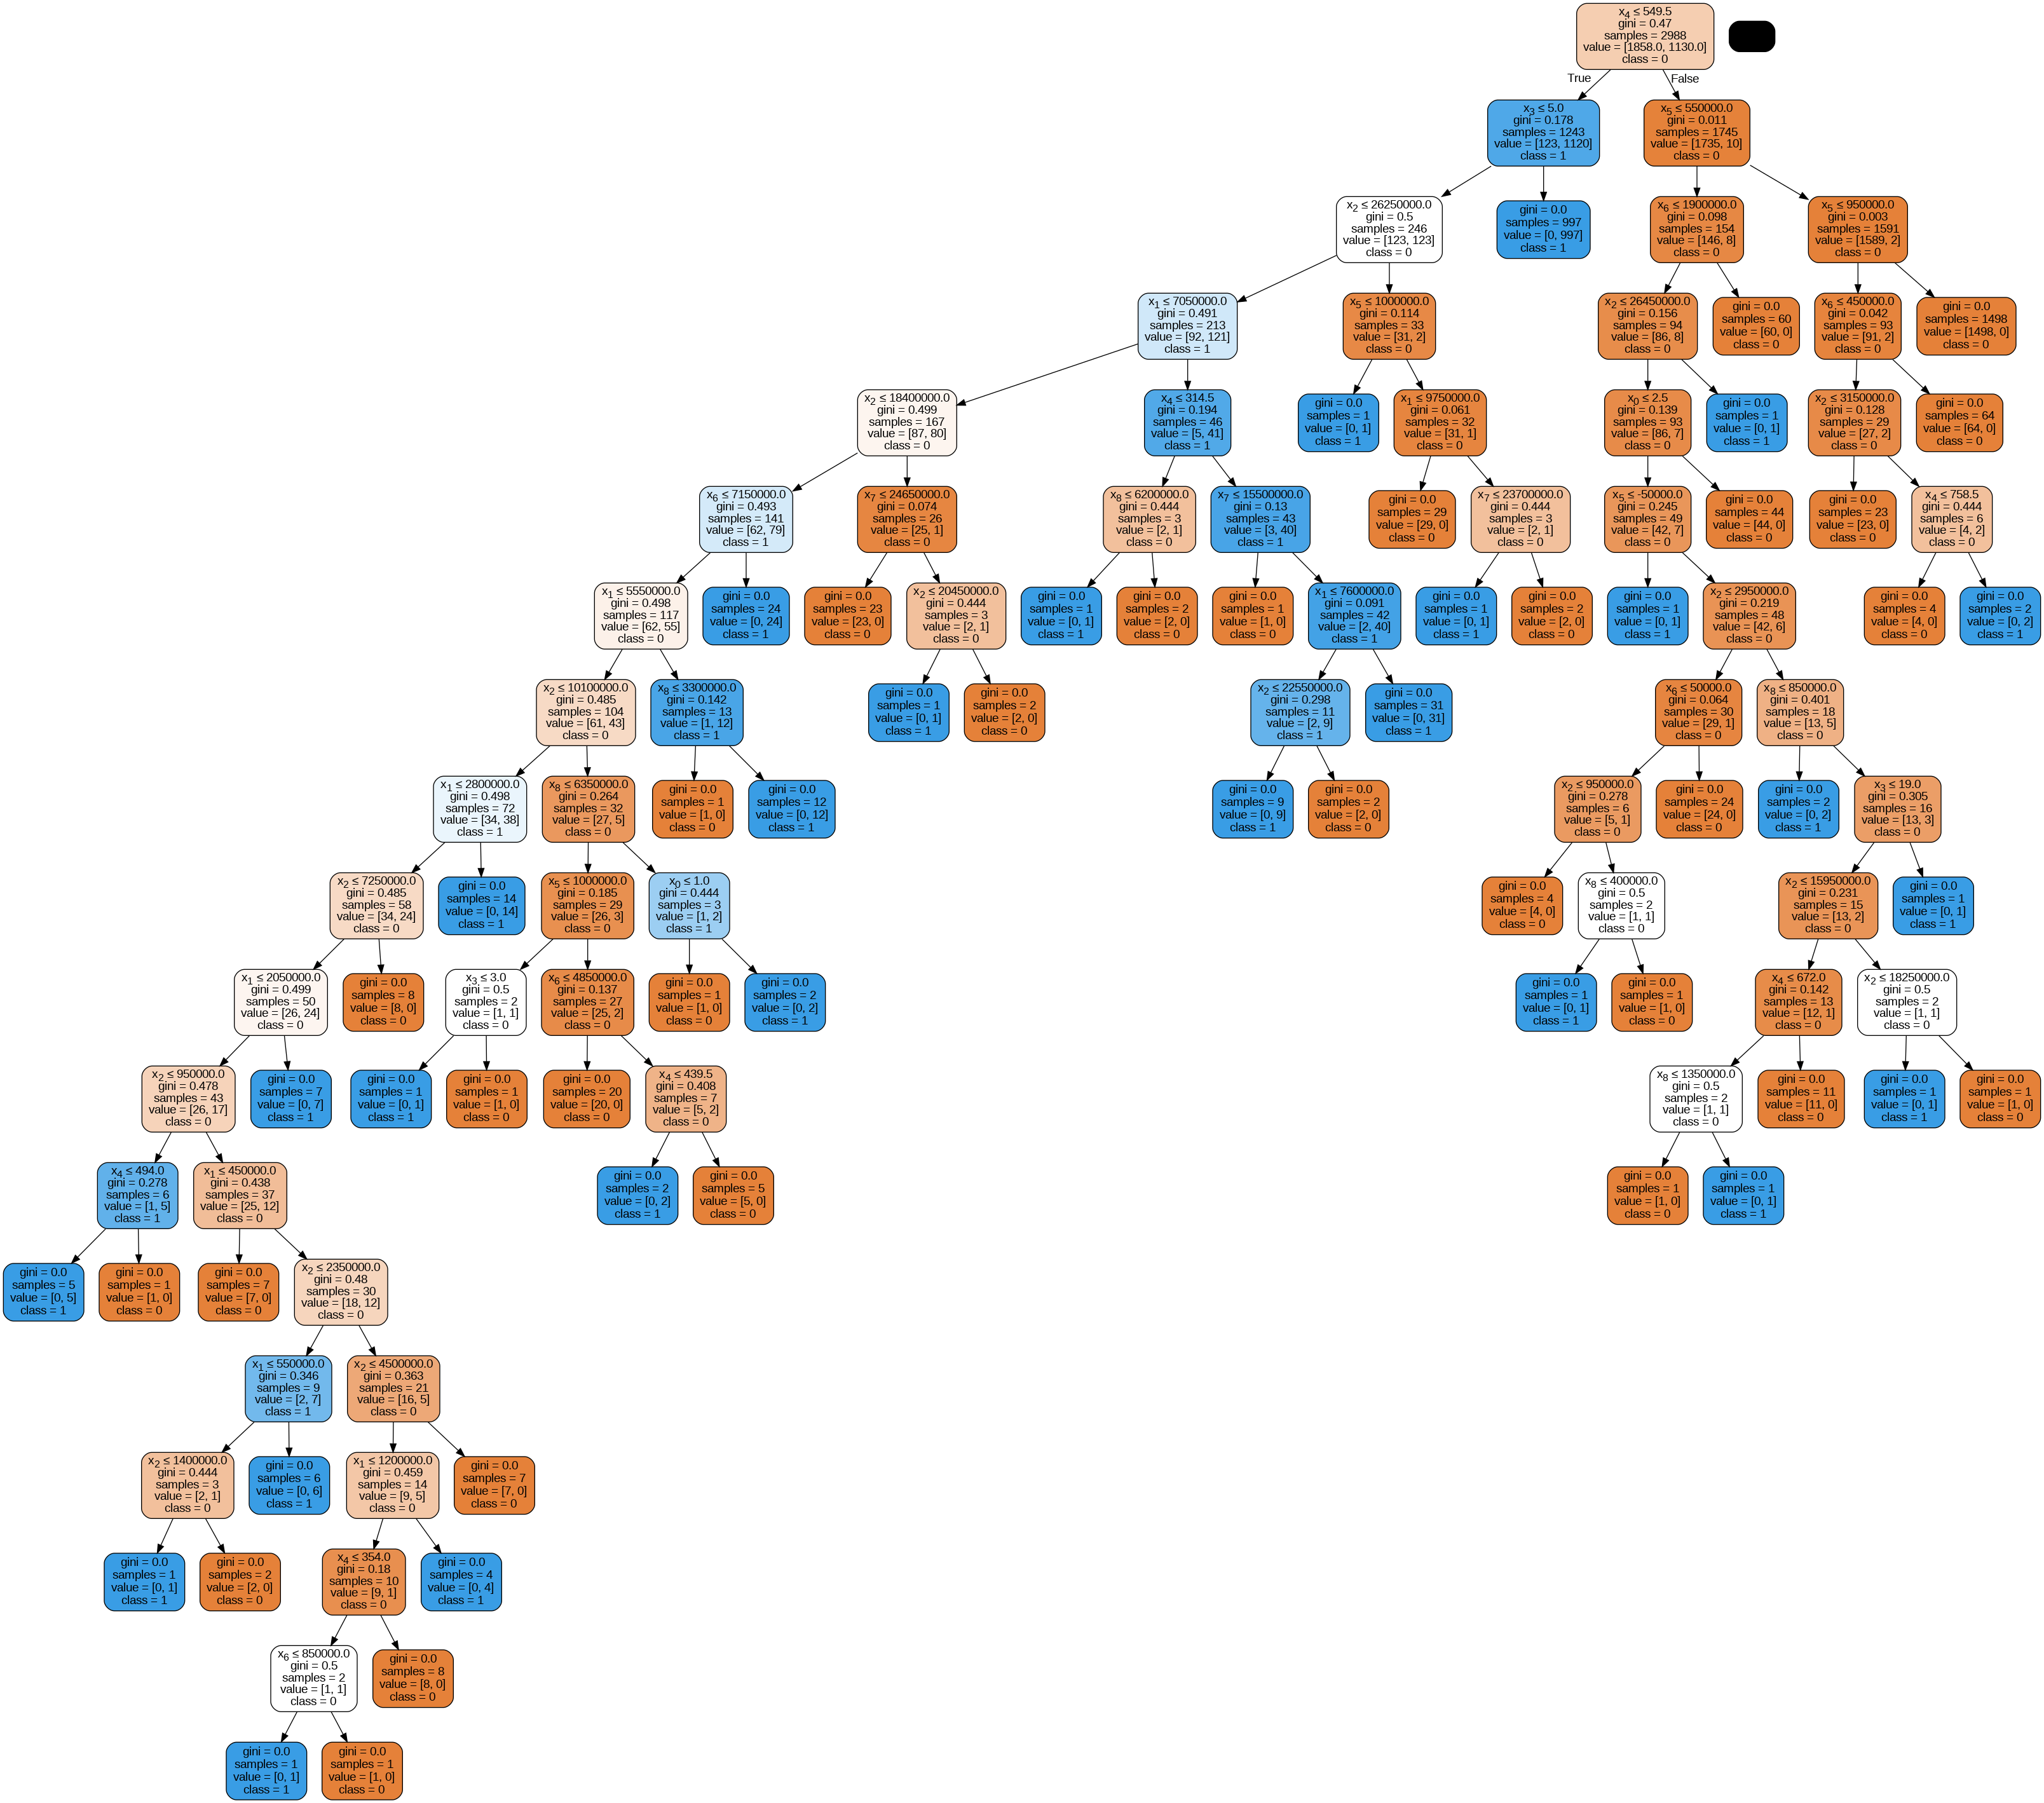

In [ ]:
dot_data = StringIO()
export_graphviz(dt_model2, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('loan_approval_dataset.png')
Image(graph.create_png())

x4 is most important feature. Which is the c_score
gini = 0.47 — measures impurity. 0 = perfectly pure (all one class), 0.5 = most mixed. 0.47 means the data is very mixed at this point.
samples = 2988 — the number of training records at this node.
value = [1858.0, 1130.0] — how many samples belong to each class. 1858 are class 0 (rejected) and 1130 are class 1 (approved).
class = 0 — the majority class at this node is 0 (rejected), since 1858 > 1130.

For top 3 nodes